<a href="https://colab.research.google.com/github/rishi682/cset343/blob/main/cset343_lab_experiment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib wfdb pillow openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wfdb

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [ ]:
print("Feature data:")
display(X.head())

print("\nTarget data:")
display(y.head())

print("\nDataset shape:")
print("X:", X.shape)
print("y:", y.shape)

print("\nData types:")
print(X.dtypes)

print("\nMissing values:")
print(X.isnull().sum())

Feature data:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0



Target data:


,num
0,0
1,2
2,1
3,0
4,0



Dataset shape:
X: (303, 13)
y: (303, 1)

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64


In [ ]:
print("Missing values before cleaning:")
print(X.isnull().sum())

X = X.copy()

for column in X.columns:
    if X[column].dtype == "object":
        X[column] = X[column].fillna(X[column].mode()[0])
    else:
        X[column] = X[column].fillna(X[column].median())

print("\nMissing values after cleaning:")
print(X.isnull().sum())

Missing values before cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


In [ ]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

print("Original shape:", X.shape)
print("Encoded shape:", X_encoded.shape)

display(X_encoded.head())

Original shape: (303, 13)
Encoded shape: (303, 13)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [ ]:
# Convert UCI target into binary classification

y = heart_disease.data.targets["num"].astype(int)

y_binary = (y > 0).astype(int)

print("Target distribution:")
print(y_binary.value_counts())

print("\n0 = No heart disease")
print("1 = Heart disease")

Target distribution:
num
0    164
1    139
Name: count, dtype: int64

0 = No heart disease
1 = Heart disease


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions:")
print(y_pred)

Predictions:
[0 1 0 0 1 0 0 0 1 0 1 0 0 1 1 1 1 0 1 1 1 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1 0
 0 0 1 1 1 1 1 0 0 1 0 1 0 0 1 1 0 0 1 1 1 0 0 1]


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.8689
ROC-AUC  : 0.9524


Confusion Matrix:
[[27  6]
 [ 2 26]]


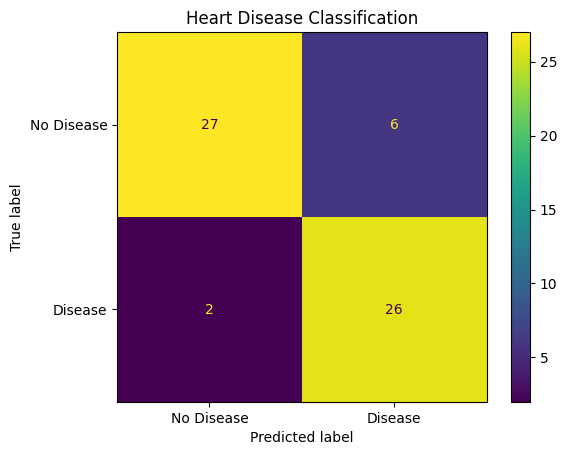

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()
plt.title("Heart Disease Classification")
plt.show()

In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

print("WFDB imported successfully!")

WFDB imported successfully!


In [ ]:
record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

print("ECG record loaded successfully!")
print("Sampling frequency:", record.fs)
print("Number of samples:", record.sig_len)
print("Number of channels:", record.n_sig)

ECG record loaded successfully!
Sampling frequency: 360
Number of samples: 650000
Number of channels: 2


In [ ]:
annotation = wfdb.rdann(
    "100",
    "atr",
    pn_dir="mitdb"
)

print("ECG annotations loaded successfully!")
print("Number of annotations:", len(annotation.sample))

ECG annotations loaded successfully!
Number of annotations: 2274


In [ ]:
signal = record.p_signal[:, 0]

print("Signal shape:", signal.shape)
print("First 10 signal values:")
print(signal[:10])

Signal shape: (650000,)
First 10 signal values:
[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]


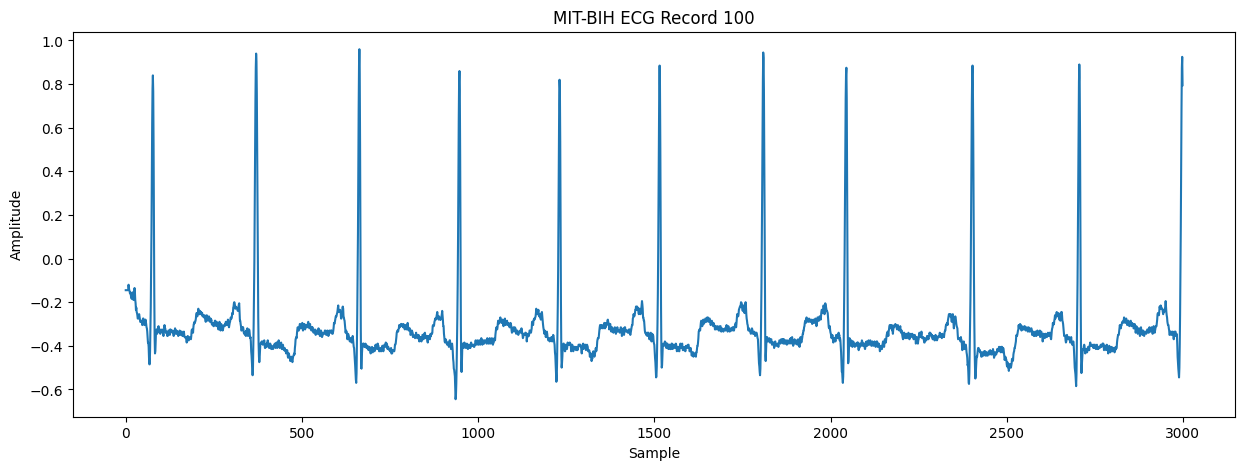

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(signal[:3000])

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("MIT-BIH ECG Record 100")

plt.show()

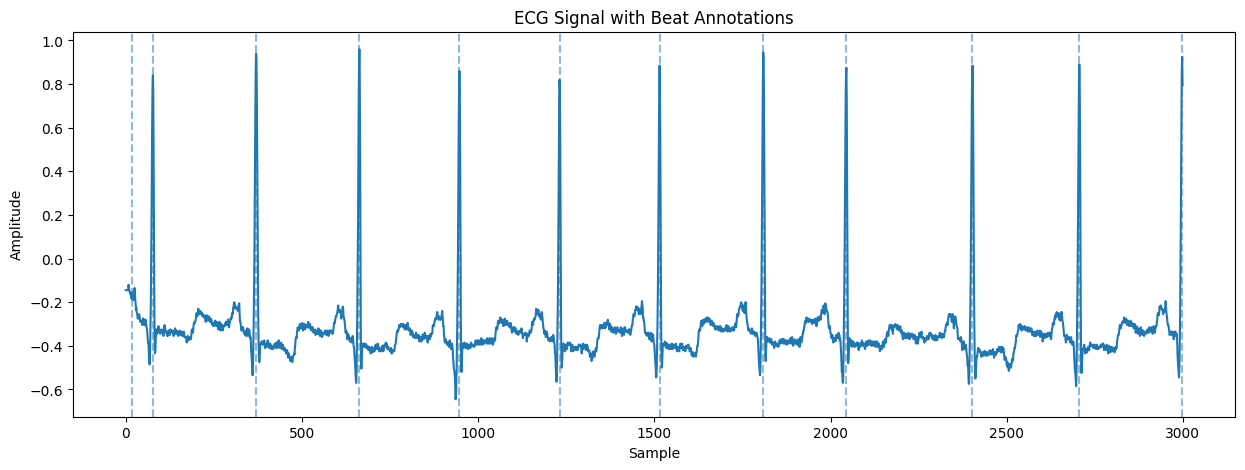

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(signal[:3000], label="ECG Signal")

for sample, symbol in zip(
    annotation.sample,
    annotation.symbol
):
    if sample < 3000:
        plt.axvline(
            sample,
            linestyle="--",
            alpha=0.5
        )

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("ECG Signal with Beat Annotations")

plt.show()

In [ ]:
beat_samples = annotation.sample

rr_intervals = np.diff(beat_samples)

print("Number of beat intervals:", len(rr_intervals))
print("First 10 beat intervals:")
print(rr_intervals[:10])

Number of beat intervals: 2273
First 10 beat intervals:
[ 59 293 292 284 285 284 294 235 358 304]


In [ ]:
rr_seconds = rr_intervals / record.fs

print("First 10 RR intervals in seconds:")
print(rr_seconds[:10])

First 10 RR intervals in seconds:
[0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444]


In [ ]:
heart_rates = 60 / rr_seconds

print("Average Heart Rate:",
      round(np.mean(heart_rates), 2),
      "BPM")

print("Median Heart Rate:",
      round(np.median(heart_rates), 2),
      "BPM")

Average Heart Rate: 75.94 BPM
Median Heart Rate: 75.26 BPM


In [ ]:
rr_std = np.std(rr_seconds)

print("RR Interval Standard Deviation:",
      round(rr_std, 4),
      "seconds")

RR Interval Standard Deviation: 0.0506 seconds
